In [5]:
%run -i ../python_scripts/nb_setup.py
from joblib import cpu_count

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [6]:
n_cpus = cpu_count()

#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [7]:
sgp_df = pickle.load(open("../experiments/CIFAR/sgp_set_cnn", "rb"))
print(
    "N =",
    sgp_df.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df.y_true.sum() / sgp_df.shape[0], 2),
)
sgp_df.head(3)

N = 40000 Proportion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295


In [8]:
deltas = [1e-3, 1e-2, 1e-1, 3e-1]
num_seed = 500
theta_min, theta_max = 0.5, 1  # Sn-independent grid
num_targets = 20  # number of targets r* to consider

In [9]:
results = []

### __0/1 risk__

In [10]:
metric_targets = np.linspace(0.03, 0.2, num=num_targets)

In [11]:
for delta in deltas:
    failures_01 = list(
        Parallel(n_jobs=n_cpus - 2)(
            delayed(
                lambda seed: run_one_seed(
                    s=seed,
                    delta=delta,
                    sgp_df=sgp_df,
                    metric="standard",
                    metric_targets=metric_targets,
                    mode="dicho",
                    theta_min=theta_min,
                    theta_max=theta_max,
                )
            )(s)
            for s in range(num_seed)
        )
    )
    failure_rate = sum(failures_01) / (num_seed * num_targets)
    results.append({"metric": "01", "delta": delta, "failure rate": failure_rate})
    print("delta:", delta, "§ failure rate:", failure_rate)

delta: 0.001 § failure rate: 0.0006
delta: 0.01 § failure rate: 0.0034
delta: 0.1 § failure rate: 0.012
delta: 0.3 § failure rate: 0.0224


### __FP risk__

In [12]:
metric_targets = np.linspace(0.03, 0.16, num=num_targets)

In [13]:
for delta in deltas:
    failures_fp = list(
        Parallel(n_jobs=n_cpus - 2)(
            delayed(
                lambda seed: run_one_seed(
                    s=seed,
                    delta=delta,
                    sgp_df=sgp_df,
                    metric="FP",
                    metric_targets=metric_targets,
                    mode="dicho",
                    theta_min=theta_min,
                    theta_max=theta_max,
                )
            )(s)
            for s in range(num_seed)
        )
    )
    failure_rate = sum(failures_fp) / (num_seed * num_targets)
    results.append({"metric": "FP risk", "delta": delta, "failure rate": failure_rate})
    print("delta:", delta, "§ failure rate:", failure_rate)

delta: 0.001 § failure rate: 0.0003
delta: 0.01 § failure rate: 0.0025
delta: 0.1 § failure rate: 0.0122
delta: 0.3 § failure rate: 0.0224


### __FN risk__

In [14]:
metric_targets = np.linspace(0.001, 0.04, num=num_targets)

In [15]:
for delta in deltas:
    failures_fn = list(
        Parallel(n_jobs=n_cpus - 2)(
            delayed(
                lambda seed: run_one_seed(
                    s=seed,
                    delta=delta,
                    sgp_df=sgp_df,
                    metric="FN",
                    metric_targets=metric_targets,
                    mode="dicho",
                    theta_min=theta_min,
                    theta_max=theta_max,
                )
            )(s)
            for s in range(num_seed)
        )
    )
    failure_rate = sum(failures_fn) / (num_seed * num_targets)
    results.append({"metric": "FN risk", "delta": delta, "failure rate": failure_rate})
    print("delta:", delta, "§ failure rate:", failure_rate)

delta: 0.001 § failure rate: 0.0005
delta: 0.01 § failure rate: 0.002
delta: 0.1 § failure rate: 0.0087
delta: 0.3 § failure rate: 0.0136


### __FPR__

In [16]:
metric_targets = np.linspace(0.01, 0.2, num=num_targets)

In [17]:
for delta in deltas:
    failures_fpr = list(
        Parallel(n_jobs=n_cpus - 2)(
            delayed(
                lambda seed: run_one_seed(
                    s=seed,
                    delta=delta,
                    sgp_df=sgp_df,
                    metric="FPR",
                    metric_targets=metric_targets,
                    mode="greedy",
                    theta_min=theta_min,
                    theta_max=theta_max,
                )
            )(s)
            for s in range(num_seed)
        )
    )
    failure_rate = sum(failures_fpr) / (num_seed * num_targets)
    results.append({"metric": "FPR", "delta": delta, "failure rate": failure_rate})
    print("delta:", delta, "§ failure rate:", failure_rate)

delta: 0.001 § failure rate: 0.0
delta: 0.01 § failure rate: 0.0
delta: 0.1 § failure rate: 0.0012
delta: 0.3 § failure rate: 0.0037


### __FNR__

In [18]:
metric_targets = np.linspace(0.1, 0.35, num=num_targets)

In [19]:
for delta in deltas:
    failures_fnr = list(
        Parallel(n_jobs=n_cpus - 2)(
            delayed(
                lambda seed: run_one_seed(
                    s=seed,
                    delta=delta,
                    sgp_df=sgp_df,
                    metric="FNR",
                    metric_targets=metric_targets,
                    mode="greedy",
                    theta_min=theta_min,
                    theta_max=theta_max,
                )
            )(s)
            for s in range(num_seed)
        )
    )
    failure_rate = sum(failures_fnr) / (num_seed * num_targets)
    results.append({"metric": "FNR", "delta": delta, "failure rate": failure_rate})
    print("delta:", delta, "§ failure rate:", failure_rate)

delta: 0.001 § failure rate: 0.0
delta: 0.01 § failure rate: 0.0
delta: 0.1 § failure rate: 0.0
delta: 0.3 § failure rate: 0.0


In [20]:
pickle.dump(results, open("failure_rates", "wb"))

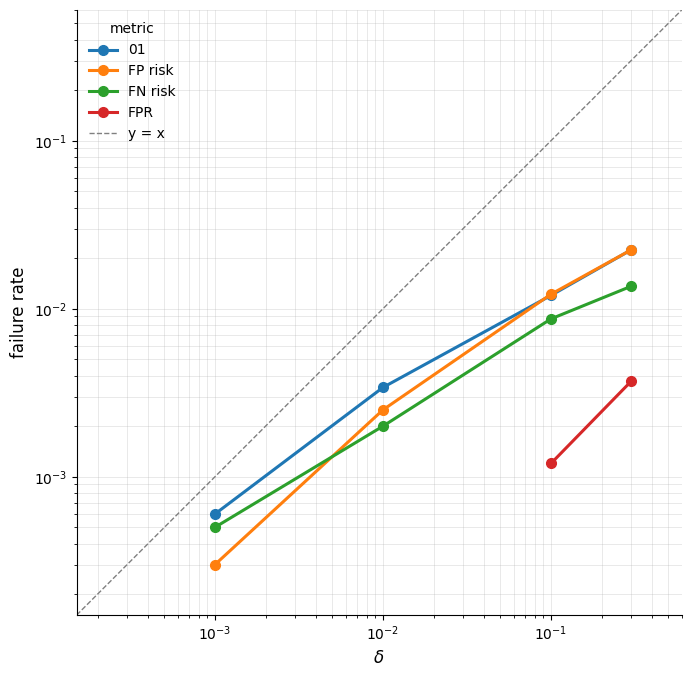

Note: 6 rows with failure rate = 0 were omitted (cannot plot on log scale).


In [15]:
df = pd.DataFrame(pickle.load(open("failure_rates", "rb")))

fig, ax = plt.subplots(figsize=(7, 7), dpi=100)

metrics = df["metric"].unique()
cmap = plt.get_cmap("tab10")
colors = {m: cmap(i) for i, m in enumerate(metrics)}

for metric, sub in df.groupby("metric", sort=False):
    sub = sub.sort_values("delta")
    # log axes can't show zeros -> keep only strictly positive failure rates
    sub = sub[sub["failure rate"] > 0]
    if sub.empty:
        continue
    ax.plot(
        sub["delta"],
        sub["failure rate"],
        marker="o",
        markersize=7,
        linewidth=2.2,
        color=colors[metric],
        label=metric,
    )

ax.set_xscale("log")
ax.set_yscale("log")

# common log range for both axes, computed from positive values only
pos = df[df["failure rate"] > 0]
lo = min(df["delta"].min(), pos["failure rate"].min())
hi = max(df["delta"].max(), pos["failure rate"].max())
# pad by one "decade fraction" on each side
import numpy as np

lo *= 0.5
hi *= 2
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")  # equal decades on both axes
# y = x reference (failure rate == delta)
ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1, label="y = x")
ax.set_xlabel(r"$\delta$", fontsize=12)
ax.set_ylabel("failure rate", fontsize=12)
ax.grid(True, which="both", linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="metric", frameon=False, fontsize=10)

fig.tight_layout()
plt.show()

# report dropped zero rows
n_dropped = (df["failure rate"] <= 0).sum()
if n_dropped:
    print(
        f"Note: {n_dropped} rows with failure rate = 0 were omitted (cannot plot on log scale)."
    )